<a href="https://colab.research.google.com/github/An4PDM/SVM-evasao-escolar-INEP/blob/main/SVM_Evasao_Escolar_2025_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Modelo Preditivo para Taxa de Evasão Escolar com dados do INEP (2025)**

**Objetivo Geral:** Prever o risco/taxa de abandono escolar das escolas a partir das características observadas no Censo Escolar de 2025.

A taxa de evasão não vem pronta nos microdados brutos do Censo Escolar (matrícula, docentes, turmas). O INEP publica separadamente os Indicadores Educacionais, especificamente as "Taxas de Rendimento Escolar" (aprovação, reprovação e abandono), calculadas a partir do Censo Escolar e disponibilizadas por escola/município/estado, ano a ano. É esse indicador de abandono que será o nosso alvo (target).

O modelo será supervisionado. A ideia inicial era tratar o abandono como uma taxa contínua (regressão), mas o problema foi reformulado como uma classificação binária (a escola teve ou não abandono no Ensino Fundamental), já que a distribuição da taxa é fortemente concentrada em 0% e o objetivo prático é sinalizar risco de abandono, e não estimar o percentual exato.

Será usado o dataset de Microdados do Censo Escolar de 2025 e o arquivo de Rendimento Escolar, disponíveis nos links abaixo:

 [Censo Escolar - 2025](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-escolar?utm_source)

[Indicadores de Taxa de Rendimento Escolar - 2025](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/indicadores-educacionais/taxas-de-rendimento-escolar?utm_source)


X = características da escola

y = indicador binário de abandono (0 = não houve, 1 = houve)

Optou-se por carregar os dados no Google Drive por serem extensos, facilitando na organização e carregamentos posteriores no Google Colab.

Link: [Pasta com arquivos utilizados](https://drive.google.com/drive/folders/1eq5qc70Tz7kmm-NT4DrFt7iE9otFYSXv?usp=sharing)

In [1]:
# Importação das bibliotecas
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier

# Configuração de acesso ao drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Carregamento dos dados salvos em uma pasta do Google Drive
dicionario = pd.read_excel('/content/drive/MyDrive/SUMMIT/microdados_censo_escolar_2025_v2/Anexos/ANEXO I - Dicionário de Dados/dicionário_dados_educação_básica.xlsx')

docentes = pd.read_csv('/content/drive/MyDrive/SUMMIT/microdados_censo_escolar_2025_v2/dados/Tabela_Docente_2025_V2.csv', sep=';', encoding='latin-1')
escolas = pd.read_csv('/content/drive/MyDrive/SUMMIT/microdados_censo_escolar_2025_v2/dados/Tabela_Escola_2025_V2.csv', sep=';', encoding='latin-1')
matriculas = pd.read_csv('/content/drive/MyDrive/SUMMIT/microdados_censo_escolar_2025_v2/dados/Tabela_Matricula_2025_V2.csv', sep=';', encoding='latin-1')
turmas = pd.read_csv('/content/drive/MyDrive/SUMMIT/microdados_censo_escolar_2025_v2/dados/Tabela_Turma_2025_V2.csv', sep=';', encoding='latin-1')
rendimento = pd.read_excel('/content/drive/MyDrive/SUMMIT/Taxas de Rendimento Escolar/tx_rend_escolas_2025.xlsx', header=8)

/tmp/ipykernel_2552/2812678457.py:4: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  docentes = pd.read_csv('/content/drive/MyDrive/SUMMIT/microdados_censo_escolar_2025_v2/dados/Tabela_Docente_2025_V2.csv', sep=';', encoding='latin-1')
/tmp/ipykernel_2552/2812678457.py:5: DtypeWarning: Columns (14,24) have mixed types. Specify dtype option on import or set low_memory=False.
  escolas = pd.read_csv('/content/drive/MyDrive/SUMMIT/microdados_censo_escolar_2025_v2/dados/Tabela_Escola_2025_V2.csv', sep=';', encoding='latin-1')
/tmp/ipykernel_2552/2812678457.py:6: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  matriculas = pd.read_csv('/content/drive/MyDrive/SUMMIT/microdados_censo_escolar_2025_v2/dados/Tabela_Matricula_2025_V2.csv', sep=';', encoding='latin-1')
/tmp/ipykernel_2552/2812678457.py:7: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set lo

#### **1. Análise Geral dos dados do Censo Escolar**

Abaixo, está uma visão geral de cada tabela.

In [3]:
# Informações sobre docentes
print(docentes.shape)
display(docentes.head())

(178772, 184)


,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,QT_DOC_BAS_DISC_EST_SOCIAIS,QT_DOC_BAS_DISC_EST_SOCIAIS_SOCI,QT_DOC_BAS_DISC_INFO_COMPUTACAO,QT_DOC_BAS_DISC_ENSINO_RELIGIOSO,QT_DOC_BAS_DISC_PROFISSIONA,QT_DOC_BAS_DISC_ESTAGIO_SUPER,QT_DOC_BAS_DISC_PEDAGOGICAS,QT_DOC_BAS_DISC_PROJETO_DE_VIDA,QT_DOC_BAS_DISC_OUTRAS,QT_DOC_BAS_LIBRAS
0,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,1,0,0,0,0,0,0
1,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,1,0,1,0,0,0,0,5,0
2,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,6,0,0,0,0,1,0
3,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,4,0,0,0,0,0,9,13,0
4,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,3,0,0,0,0,1,0


In [4]:
# Informações sobre as escolas
print(escolas.shape)
display(escolas.head())

(214192, 290)


,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,IN_ESP_EXCLUSIVA_MEDIO_FIC,IN_ESP_EXCLUSIVA_MEDIO_NORMAL,IN_COMUM_EJA_FUND,IN_COMUM_EJA_MEDIO,IN_COMUM_EJA_PROF,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_COMUM_PROF,IN_ESP_EXCLUSIVA_PROF
0,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Informações sobre matrículas/alunos
print(matriculas.shape)
display(matriculas.head())

(178766, 263)


,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,QT_MAT_ESP_INT,QT_MAT_ESP_CC_INT,QT_MAT_ESP_CE_INT,QT_MAT_BAS_LIBRAS,QT_MAT_ZR_URB,QT_MAT_ZR_RUR,QT_MAT_ZR_NA,QT_TRANSP_PUBLICO,QT_TRANSP_RESP_EST,QT_TRANSP_RESP_MUN
0,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,0,0,4,0,0,0,0
1,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,0,81,27,0,0,0,0
2,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,0,3,161,0,130,0,130
3,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,11,11,0,0,253,303,0,258,0,258
4,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,0,0,60,0,53,0,53


In [6]:
# Informações das turmas
print(turmas.shape)
display(turmas.head())

(178772, 218)


,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,QT_TUR_BAS_DISC_EST_SOCIAIS,QT_TUR_BAS_DISC_EST_SOCIAIS_SOCI,QT_TUR_BAS_DISC_INFO_COMPUTACAO,QT_TUR_BAS_DISC_ENSINO_RELIGIOSO,QT_TUR_BAS_DISC_PROFISSIONA,QT_TUR_BAS_DISC_ESTAGIO_SUPER,QT_TUR_BAS_DISC_PEDAGOGICAS,QT_TUR_BAS_DISC_PROJETO_DE_VIDA,QT_TUR_BAS_DISC_OUTRAS,QT_TUR_BAS_LIBRAS
0,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,4,0,0,0,0,0,0
1,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,2,0,1,0,0,0,0,5,0
2,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,9,0,0,0,0,4,0
3,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,28,0,0,0,0,0,28,34,0
4,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,5,0,0,0,0,3,0


Observou-se que as tabelas possuem muitas colunas, então foi necessário definir as variáveis candidatas com base no dicionário de dados (dicionário_dados_educação_básica.xlsx), que mostra o contexto de cada coluna.

Para os dados de escolas, serão consideradas as seguintes colunas: CO_REGIAO, CO_ENTIDADE, CO_REDE, TP_DEPENDENCIA, TP_LOCALIZACAO, TP_LOCALIZACAO_DIFERENCIADA, IN_EXAME_SELECAO, TP_PROPOSTA_PEDAGOGICA e IN_ORGAO_CONSELHO_ESCOLAR.

- CO_REGIAO: Código da região geográfica
- CO_ENTIDADE: Código identificador da escola
- CO_REDE: Identifica o tipo de rede de ensino (1 - Pública; 2 - Privada)
- TP_DEPENDENCIA: Tipo de dependencia administrativa (1 - Federal, 2 - Estadual, 3 - Municipal e 4 - Privada)
- TP_LOCALIZACAO: Tipo da localização (1 - Urbana; 2 - Rural)
- TP_LOCALIZACAO_DIFERENCIADA: Localização diferenciada da escola (0 - A escola não está em área de localização diferenciada; 1 - Área de assentamento; 2 - Terra indígena; 3 - Comunidade quilombola; 8 - Área onde se localizam povos e comunidades tradicionais)
- IN_EXAME_SELECAO: Indica se a escola aplica exame de seleção para ingresso de alunos (0 - Não; 1 - Sim; 9 - Não classificada)
- TP_PROPOSTA_PEDAGOGICA: Indica se o projeto político-pedagógico da escola foi atualizado nos últimos 12 meses (conforme art. 12 da LDB) (0 - Não; 1 - Sim; 2 - Escola em processo de implantação; 9 - Não classificada)
- IN_ORGAO_CONSELHO_ESCOLAR: Indica se a escola possui Conselho Escolar (0 - Não; 1 - Sim)

As colunas de infraestrutura testadas anteriormente (água, energia, esgoto, banheiro, refeitório) foram descartadas do modelo final: elas se mostraram redundantes com CO_REDE/TP_DEPENDENCIA (escolas privadas quase sempre têm essa infraestrutura, escolas públicas rurais menos) e não trouxeram ganho de desempenho. As três colunas atuais (IN_EXAME_SELECAO, TP_PROPOSTA_PEDAGOGICA, IN_ORGAO_CONSELHO_ESCOLAR) foram escolhidas por representarem dimensões diferentes, seletividade, gestão pedagógica e governança, em vez de mais uma variável de infraestrutura.

Vale notar que IN_EXAME_SELECAO e TP_PROPOSTA_PEDAGOGICA têm uma categoria 9 ("não classificada"), tratada pelo OneHotEncoder como mais uma categoria válida.

In [7]:
colunas_escolas = [
    'CO_REGIAO',
    'CO_ENTIDADE',
    'CO_REDE',
    'TP_DEPENDENCIA',
    'TP_LOCALIZACAO',
    'TP_LOCALIZACAO_DIFERENCIADA',
    'IN_EXAME_SELECAO',
    'TP_PROPOSTA_PEDAGOGICA',
    'IN_ORGAO_CONSELHO_ESCOLAR'
]

filtro_escolas = escolas[colunas_escolas].copy()

In [8]:
filtro_escolas.head()

,CO_REGIAO,CO_ENTIDADE,CO_REDE,TP_DEPENDENCIA,TP_LOCALIZACAO,TP_LOCALIZACAO_DIFERENCIADA,IN_EXAME_SELECAO,TP_PROPOSTA_PEDAGOGICA,IN_ORGAO_CONSELHO_ESCOLAR
0,1,11022558,1,2,2,2.0,0.0,1.0,1.0
1,1,11024275,1,2,1,0.0,0.0,1.0,1.0
2,1,11024291,1,3,2,NaN,NaN,NaN,NaN
3,1,11024666,1,3,2,0.0,0.0,1.0,1.0
4,1,11024682,1,2,1,0.0,1.0,1.0,1.0


In [9]:
# Informa o tipo de dado das colunas e se existem valores nulos
filtro_escolas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214192 entries, 0 to 214191
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   CO_REGIAO                    214192 non-null  int64  
 1   CO_ENTIDADE                  214192 non-null  int64  
 2   CO_REDE                      214192 non-null  int64  
 3   TP_DEPENDENCIA               214192 non-null  int64  
 4   TP_LOCALIZACAO               214192 non-null  int64  
 5   TP_LOCALIZACAO_DIFERENCIADA  180540 non-null  float64
 6   IN_EXAME_SELECAO             180540 non-null  float64
 7   TP_PROPOSTA_PEDAGOGICA       180540 non-null  float64
 8   IN_ORGAO_CONSELHO_ESCOLAR    180540 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 14.7 MB


As colunas de indicador estão como float64, o que não é o correto para campo de indicador binário, então será necessário convertê-los para int64 e tratar os valores nulos presentes nas colunas 'TP_LOCALIZACAO_DIFERENCIADA', 'IN_EXAME_SELECAO', 'TP_PROPOSTA_PEDAGOGICA' e 'IN_ORGAO_CONSELHO_ESCOLAR'. Como são poucos valores nulos considerando o total de linhas, optou-se por apagar as colunas que tenham nulos nessas colunas.

In [10]:
colunas_com_nulos = ['TP_LOCALIZACAO_DIFERENCIADA', 'IN_EXAME_SELECAO', 'TP_PROPOSTA_PEDAGOGICA', 'IN_ORGAO_CONSELHO_ESCOLAR']

# Remove as linhas com nulo em qualquer um dos campos acima
filtro_escolas = filtro_escolas.dropna(subset=colunas_com_nulos)


In [11]:
# Converte de float64 para int64
filtro_escolas[colunas_com_nulos] = filtro_escolas[colunas_com_nulos].astype('int64')

In [12]:
# Quantidade de linhas e colunas
filtro_escolas.shape

(180540, 9)

A coluna CO_ENTIDADE será a chave de relacionamento.

In [13]:
# Contagem de cada valor em cada coluna
for coluna in colunas_escolas:
      print(filtro_escolas[coluna].value_counts(dropna=False))

CO_REGIAO
3    61420
2    59988
4    26272
1    22207
5    10653
Name: count, dtype: int64
CO_ENTIDADE
53020154    1
11022558    1
11024275    1
11024666    1
11024682    1
           ..
11046252    1
11039493    1
11038373    1
11038047    1
11037962    1
Name: count, Length: 180540, dtype: int64
CO_REDE
1    138086
2     42454
Name: count, dtype: int64
TP_DEPENDENCIA
3    107372
4     42454
2     29998
1       716
Name: count, dtype: int64
TP_LOCALIZACAO
1    129777
2     50763
Name: count, dtype: int64
TP_LOCALIZACAO_DIFERENCIADA
0    168068
1      4519
2      3713
3      2737
8      1503
Name: count, dtype: int64
IN_EXAME_SELECAO
0    172757
1      7584
9       199
Name: count, dtype: int64
TP_PROPOSTA_PEDAGOGICA
1    137694
0     36663
2      5105
9      1078
Name: count, dtype: int64
IN_ORGAO_CONSELHO_ESCOLAR
1    119238
0     61302
Name: count, dtype: int64


In [14]:
# Contagem de valores duplicados na coluna de relacionamento CO_ENTIDADE
print("Escolas:", escolas['CO_ENTIDADE'].duplicated().sum())
print("Matrículas:", matriculas['CO_ENTIDADE'].duplicated().sum())
print("Docentes:", docentes['CO_ENTIDADE'].duplicated().sum())
print("Turmas:", turmas['CO_ENTIDADE'].duplicated().sum())

Escolas: 0
Matrículas: 0
Docentes: 0
Turmas: 0


#### **2. Análise Geral dos dados de Rendimento Escolar**

In [15]:
rendimento.head()

,NU_ANO_CENSO,NO_REGIAO,SG_UF,CO_MUNICIPIO,NO_MUNICIPIO,CO_ENTIDADE,NO_ENTIDADE,NO_CATEGORIA,NO_DEPENDENCIA,1_CAT_FUN,...,3_CAT_FUN_06,3_CAT_FUN_07,3_CAT_FUN_08,3_CAT_FUN_09,3_CAT_MED,3_CAT_MED_01,3_CAT_MED_02,3_CAT_MED_03,3_CAT_MED_04,3_CAT_MED_NS
0,2025,Norte,RO,1100015.0,Alta Floresta D'Oeste,11022558.0,EIEEF HAP BITT TUPARI,Rural,Estadual,100,...,--,--,--,--,--,--,--,--,--,--
1,2025,Norte,RO,1100015.0,Alta Floresta D'Oeste,11024372.0,EMEIEF ANA NERY,Rural,Municipal,98.6,...,0,0,0,0,--,--,--,--,--,--
2,2025,Norte,RO,1100015.0,Alta Floresta D'Oeste,11024666.0,EMEIEF BOA ESPERANCA,Rural,Municipal,98.4,...,0,0,0,0,--,--,--,--,--,--
3,2025,Norte,RO,1100015.0,Alta Floresta D'Oeste,11024682.0,EEEFM EURIDICE LOPES PEDROSO,Urbana,Estadual,98.9,...,0,0,0,0,0,0,0,0,--,--
4,2025,Norte,RO,1100015.0,Alta Floresta D'Oeste,11024828.0,EMEIEF IZIDORO STEDILE,Rural,Municipal,96.5,...,0,0,0,0,--,--,--,--,--,--


In [16]:
rendimento.shape

(126686, 63)

In [17]:
rendimento.columns.tolist()

['NU_ANO_CENSO',
 'NO_REGIAO',
 'SG_UF',
 'CO_MUNICIPIO',
 'NO_MUNICIPIO',
 'CO_ENTIDADE',
 'NO_ENTIDADE',
 'NO_CATEGORIA',
 'NO_DEPENDENCIA',
 '1_CAT_FUN',
 '1_CAT_FUN_AI',
 '1_CAT_FUN_AF',
 '1_CAT_FUN_01',
 '1_CAT_FUN_02',
 '1_CAT_FUN_03',
 '1_CAT_FUN_04',
 '1_CAT_FUN_05',
 '1_CAT_FUN_06',
 '1_CAT_FUN_07',
 '1_CAT_FUN_08',
 '1_CAT_FUN_09',
 '1_CAT_MED',
 '1_CAT_MED_01',
 '1_CAT_MED_02',
 '1_CAT_MED_03',
 '1_CAT_MED_04',
 '1_CAT_MED_NS',
 '2_CAT_FUN',
 '2_CAT_FUN_AI',
 '2_CAT_FUN_AF',
 '2_CAT_FUN_01',
 '2_CAT_FUN_02',
 '2_CAT_FUN_03',
 '2_CAT_FUN_04',
 '2_CAT_FUN_05',
 '2_CAT_FUN_06',
 '2_CAT_FUN_07',
 '2_CAT_FUN_08',
 '2_CAT_FUN_09',
 '2_CAT_MED',
 '2_CAT_MED_01',
 '2_CAT_MED_02',
 '2_CAT_MED_03',
 '2_CAT_MED_04',
 '2_CAT_MED_NS',
 '3_CAT_FUN',
 '3_CAT_FUN_AI',
 '3_CAT_FUN_AF',
 '3_CAT_FUN_01',
 '3_CAT_FUN_02',
 '3_CAT_FUN_03',
 '3_CAT_FUN_04',
 '3_CAT_FUN_05',
 '3_CAT_FUN_06',
 '3_CAT_FUN_07',
 '3_CAT_FUN_08',
 '3_CAT_FUN_09',
 '3_CAT_MED',
 '3_CAT_MED_01',
 '3_CAT_MED_02',
 '3_CAT_

In [18]:
colunas_rendimento = [
    'CO_ENTIDADE',
    '3_CAT_FUN', # Taxa média de abandono EF 8 e 9 anos
    '3_CAT_MED' # Taxa média de abandono Ensino Médio
]

In [19]:
filtro_rendimento = rendimento[colunas_rendimento].copy()

In [20]:
filtro_rendimento.head()

,CO_ENTIDADE,3_CAT_FUN,3_CAT_MED
0,11022558.0,0,--
1,11024372.0,0,--
2,11024666.0,0,--
3,11024682.0,0,0
4,11024828.0,0,--


In [21]:
filtro_rendimento.shape

(126686, 3)

In [22]:
filtro_rendimento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126686 entries, 0 to 126685
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CO_ENTIDADE  126684 non-null  float64
 1   3_CAT_FUN    126684 non-null  object 
 2   3_CAT_MED    126684 non-null  object 
dtypes: float64(1), object(2)
memory usage: 2.9+ MB


- CO_ENTIDADE está como float64 o que é estranho para um identificador.
- As taxas 3_CAT_FUN e 3_CAT_MED estão como object, já que os valores vieram como texto (--).
- Temos 126.686 registros, mas 2 estão sem CO_ENTIDADE.

In [23]:
# Existem duas linhas com valores nulos
filtro_rendimento.isnull().sum()

,0
CO_ENTIDADE,2
3_CAT_FUN,2
3_CAT_MED,2


Como CO_ENTIDADE é justamente o identificador que vamos usar para relacionar o rendimento com a escola, não podemos aproveitar essas duas linhas, então será necessário removê-las.

In [24]:
filtro_rendimento = filtro_rendimento.dropna(subset=['CO_ENTIDADE'])

In [25]:
filtro_rendimento['3_CAT_FUN'].unique()[:20]

array([0, 0.9, 1.5, 0.2, '--', 3.3, 0.8, 1.9, 0.6, 0.4, 0.7, 2.1, 0.5, 1,
       2.9, 3.5, 4, 0.3, 0.1, 5.6], dtype=object)

In [26]:
filtro_rendimento['3_CAT_MED'].unique()[:20]

array(['--', 0, 1, 8.8, 0.3, 15.4, 9.8, 2, 3.1, 6, 1.2, 8.5, 7.2, 0.5,
       9.1, 3.9, 18.2, 1.7, 6.7, 3.4], dtype=object)

Nas colunas de taxa, existem valores como "--" que representam ausência de informação, então esses valores serão convertidos para NaN. E logo em seguida, as colunas terão os tipos convertidos para float

In [27]:
# Substitui '--' por NaN
filtro_rendimento[['3_CAT_FUN', '3_CAT_MED']] = (
    filtro_rendimento[['3_CAT_FUN', '3_CAT_MED']]
    .replace('--', np.nan)
)

/tmp/ipykernel_2552/2467500550.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace('--', np.nan)


In [28]:
# Converte as taxas para números
filtro_rendimento[['3_CAT_FUN', '3_CAT_MED']] = (
    filtro_rendimento[['3_CAT_FUN', '3_CAT_MED']]
    .astype(float)
)

In [29]:
filtro_rendimento.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126684 entries, 0 to 126683
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CO_ENTIDADE  126684 non-null  float64
 1   3_CAT_FUN    116885 non-null  float64
 2   3_CAT_MED    30086 non-null   float64
dtypes: float64(3)
memory usage: 3.9 MB


In [30]:
filtro_rendimento.isnull().sum()

,0
CO_ENTIDADE,0
3_CAT_FUN,9799
3_CAT_MED,96598


In [31]:
filtro_rendimento[['3_CAT_FUN', '3_CAT_MED']].describe()

,3_CAT_FUN,3_CAT_MED
count,116885.000000,30086.000000
mean,0.569893,1.926667
std,2.463018,4.298263
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,2.500000
max,100.000000,100.000000


Existe uma concentração muito grande em 0 em ambas as colunas. Além disso, o valor máximo 100 para as duas poderia indicar 100% de abandono naquela etapa, ou então possíveis outliers.

In [32]:
print((filtro_rendimento['3_CAT_FUN'] == 0).sum())
print((filtro_rendimento['3_CAT_MED'] == 0).sum())

88846
15975


In [33]:
filtro_rendimento['3_CAT_FUN'].value_counts().sort_index().head(10)

,count
3_CAT_FUN,
0.0,88846
0.1,606
0.2,1623
0.3,1907
0.4,1791
0.5,1614
0.6,1393
0.7,1276
0.8,1114


In [34]:
filtro_rendimento['3_CAT_MED'].value_counts().sort_index().head(10)

,count
3_CAT_MED,
0.0,15975
0.1,92
0.2,322
0.3,337
0.4,351
0.5,346
0.6,359
0.7,298
0.8,320


In [35]:
filtro_rendimento[filtro_rendimento['3_CAT_FUN'] == 100].count()

,0
CO_ENTIDADE,11
3_CAT_FUN,11
3_CAT_MED,2


In [36]:
filtro_rendimento[filtro_rendimento['3_CAT_MED'] == 100].count()

,0
CO_ENTIDADE,12
3_CAT_FUN,9
3_CAT_MED,12




Analisando a tabela a seguir, identificou-se que 76% das taxas informadas do Fundamental são 0% e no Médio aproximadamente 53% são 0%.
|                    | Fundamental |  Médio |
| ------------------ | ----------: | -----: |
| Com taxa informada |     116.885 | 30.086 |
| Taxa = 0%          |      88.846 | 15.975 |
| Taxa = 100%        |          11 |     12 |


Os 100% são pouquíssimos casos, então não devemos removê-los como outliers automaticamente. Uma escola pode realmente ter todos os alunos daquela etapa classificados como abandono.


#### **3. Junção dos Dados (Escolas + Rendimento)**

A seguir, ocorre a junção dos dados de escola com os dados de rendimento por CO_ENTIDADE. Porém, antes é necessário verificar se os tipos de dado estão iguais.

In [37]:
filtro_escolas['CO_ENTIDADE'].dtype

dtype('int64')

In [38]:
filtro_rendimento['CO_ENTIDADE'].dtype

dtype('float64')

Em "filtro_rendimento", a coluna CO_ENTIDADE está como float64 e iremos alterá-la para int64 para padronização.

In [39]:
filtro_rendimento['CO_ENTIDADE'] = filtro_rendimento['CO_ENTIDADE'].astype('int64')

In [40]:
filtro_rendimento['CO_ENTIDADE'].dtype

dtype('int64')

Por fim, o bloco a seguir permite cruzar os dados com o "merge" através da coluna CO_ENTIDADE

In [41]:
df = filtro_escolas.merge(filtro_rendimento, how='inner', on='CO_ENTIDADE')

In [42]:
df.head()

,CO_REGIAO,CO_ENTIDADE,CO_REDE,TP_DEPENDENCIA,TP_LOCALIZACAO,TP_LOCALIZACAO_DIFERENCIADA,IN_EXAME_SELECAO,TP_PROPOSTA_PEDAGOGICA,IN_ORGAO_CONSELHO_ESCOLAR,3_CAT_FUN,3_CAT_MED
0,1,11022558,1,2,2,2,0,1,1,0.0,NaN
1,1,11024666,1,3,2,0,0,1,1,0.0,NaN
2,1,11024682,1,2,1,0,1,1,1,0.0,0.0
3,1,11024917,1,3,2,0,0,1,1,0.0,NaN
4,1,11024968,1,2,1,0,0,1,1,0.9,1.0


In [43]:
df.shape

(126684, 11)

In [44]:
df.isnull().sum()

,0
CO_REGIAO,0
CO_ENTIDADE,0
CO_REDE,0
TP_DEPENDENCIA,0
TP_LOCALIZACAO,0
TP_LOCALIZACAO_DIFERENCIADA,0
IN_EXAME_SELECAO,0
TP_PROPOSTA_PEDAGOGICA,0
IN_ORGAO_CONSELHO_ESCOLAR,0
3_CAT_FUN,9799


Para esse primeiro momento, o target escolhido foi 3_CAT_FUN, que corresponde a Taxa de Abandono no Ensino Fundamental, já que temos menos valores nulos presentes. Portanto, a coluna "3_CAT_MED" será removida do dataframe por enquanto. Além disso, selecionaremos apenas as linhas que possuem preenchimento em 3_CAT_FUN.

In [45]:
# Remove as linhas que possuem valor nulo em 3_CAT_FUN
df = df.dropna(subset=['3_CAT_FUN'])

In [46]:
# Remoção da coluna 3_CAT_MED
df = df.drop(columns=['3_CAT_MED'])

In [47]:
# Informações gerais do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116885 entries, 0 to 126683
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   CO_REGIAO                    116885 non-null  int64  
 1   CO_ENTIDADE                  116885 non-null  int64  
 2   CO_REDE                      116885 non-null  int64  
 3   TP_DEPENDENCIA               116885 non-null  int64  
 4   TP_LOCALIZACAO               116885 non-null  int64  
 5   TP_LOCALIZACAO_DIFERENCIADA  116885 non-null  int64  
 6   IN_EXAME_SELECAO             116885 non-null  int64  
 7   TP_PROPOSTA_PEDAGOGICA       116885 non-null  int64  
 8   IN_ORGAO_CONSELHO_ESCOLAR    116885 non-null  int64  
 9   3_CAT_FUN                    116885 non-null  float64
dtypes: float64(1), int64(9)
memory usage: 9.8 MB


In [48]:
df[['CO_REGIAO','CO_REDE','TP_DEPENDENCIA','TP_LOCALIZACAO','TP_LOCALIZACAO_DIFERENCIADA','3_CAT_FUN']].describe()

,CO_REGIAO,CO_REDE,TP_DEPENDENCIA,TP_LOCALIZACAO,TP_LOCALIZACAO_DIFERENCIADA,3_CAT_FUN
count,116885.000000,116885.000000,116885.000000,116885.000000,116885.000000,116885.000000
mean,2.560457,1.193267,3.015691,1.374428,0.247688,0.569893
std,1.080422,0.394862,0.609486,0.483977,1.010181,2.463018
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,1.000000,3.000000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,3.000000,1.000000,0.000000,0.000000
75%,3.000000,1.000000,3.000000,2.000000,0.000000,0.000000
max,5.000000,2.000000,4.000000,2.000000,8.000000,100.000000


#### **4. Análise Exploratória dos Dados**

Distribuição das variáveis

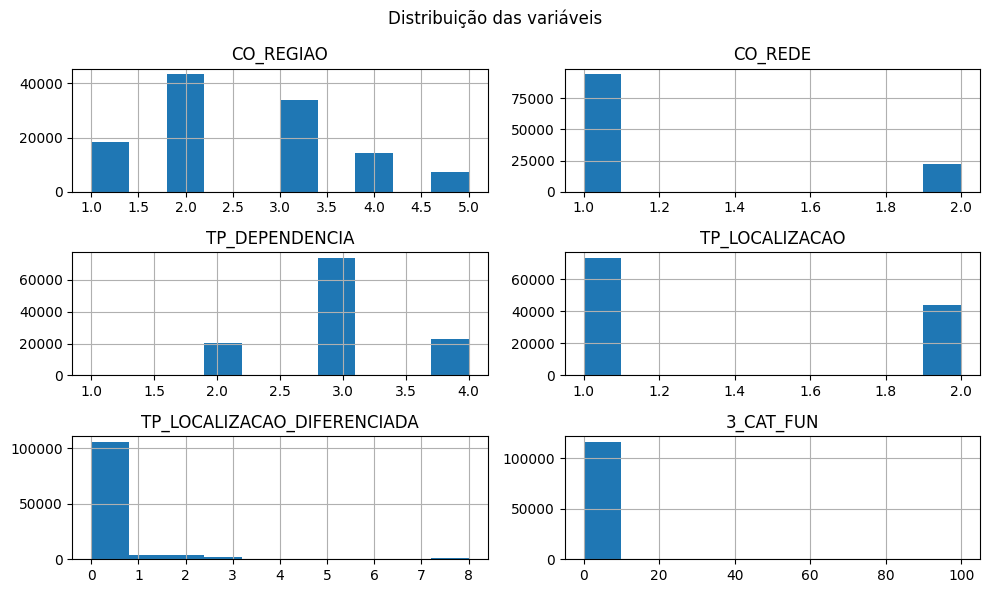

In [49]:
# Histogramas para avaliar a distribuição das variáveis
df[['CO_REGIAO','CO_REDE','TP_DEPENDENCIA','TP_LOCALIZACAO','TP_LOCALIZACAO_DIFERENCIADA','3_CAT_FUN']].hist(figsize=(10,6))
plt.suptitle("Distribuição das variáveis")
plt.tight_layout()
plt.show()

Apesar de histogramas não serem a melhor opção para visualizar variáveis categóricas, podemos observar alguns pontos:
- CO_REGIAO: há uma distribuição diferente entre as 5 regiões, com maior concentração nas regiões 2 e 3.
- CO_REDE: Predominam escolas da categoria 1.
- TP_DEPENDENCIA: a categoria 3 concentra a maior parte das escolas.
- TP_LOCALIZACAO: predominam escolas na categoria 1.
- TP_LOCALIZACAO_DIFERENCIADA: a categoria 0 domina.
- 3_CAT_FUN: A distribuição está extremamente concentrada próxima de 0%, com uma cauda chegando até 100%.

A seguir, estão os agrupamentos em relação a variável de taxa de abandono.

<Axes: xlabel='rede', ylabel='Taxa média de abandono'>

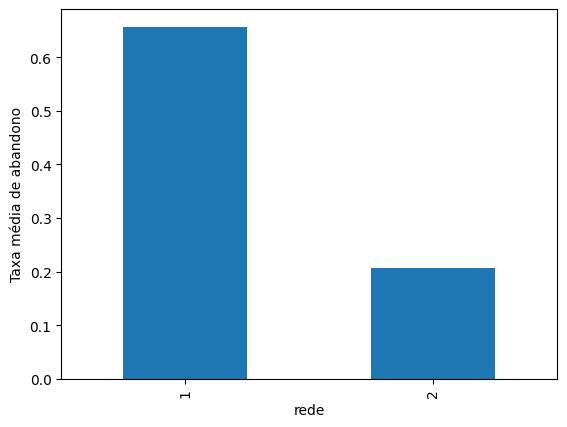

In [50]:
df.groupby('CO_REDE')['3_CAT_FUN'].mean().plot(
    kind='bar',
    xlabel='rede',
    ylabel='Taxa média de abandono'
)

<Axes: xlabel='Região', ylabel='Taxa média de abandono'>

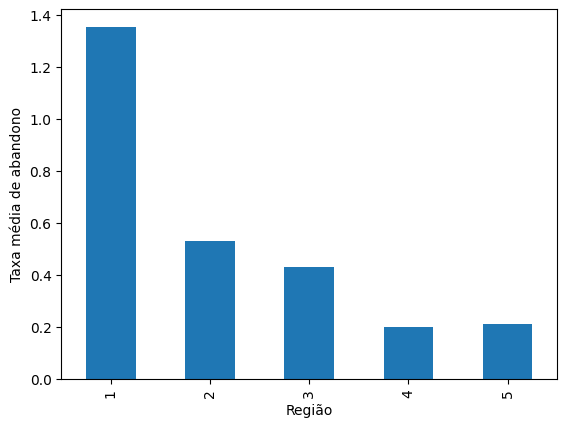

In [51]:
df.groupby('CO_REGIAO')['3_CAT_FUN'].mean().plot(
    kind='bar',
    xlabel='Região',
    ylabel='Taxa média de abandono'
)

<Axes: xlabel='Dependência', ylabel='Taxa média de abandono'>

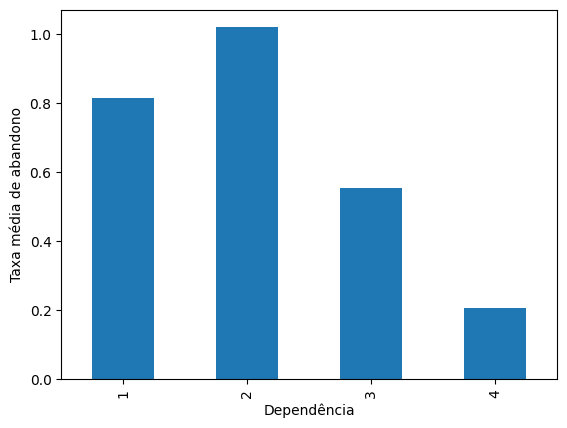

In [52]:
df.groupby('TP_DEPENDENCIA')['3_CAT_FUN'].mean().plot(
    kind='bar',
    xlabel='Dependência',
    ylabel='Taxa média de abandono'
)

<Axes: xlabel='Tipo de Localização', ylabel='Taxa média de abandono'>

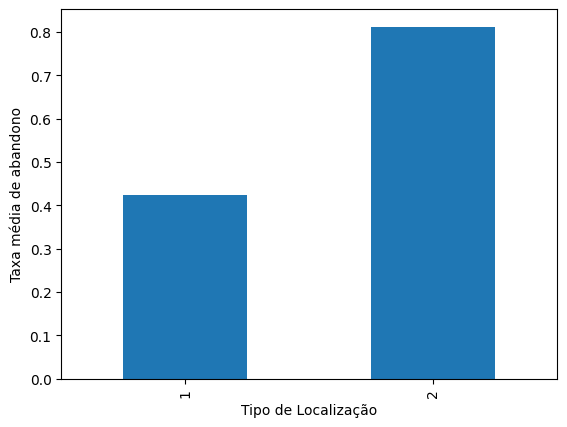

In [53]:
df.groupby('TP_LOCALIZACAO')['3_CAT_FUN'].mean().plot(
    kind='bar',
    xlabel='Tipo de Localização',
    ylabel='Taxa média de abandono'
)

<Axes: xlabel='Tipo de localização diferenciada', ylabel='Taxa média de abandono'>

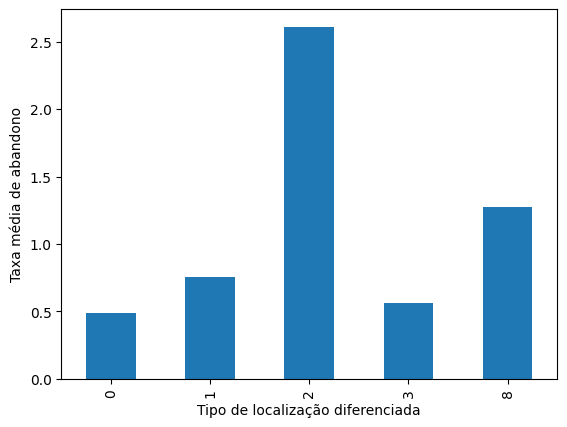

In [54]:
df.groupby('TP_LOCALIZACAO_DIFERENCIADA')['3_CAT_FUN'].mean().plot(
    kind='bar',
    xlabel='Tipo de localização diferenciada',
    ylabel='Taxa média de abandono'
)

As três variáveis adicionadas mais recentemente (IN_EXAME_SELECAO, TP_PROPOSTA_PEDAGOGICA, IN_ORGAO_CONSELHO_ESCOLAR) ainda não tinham sido exploradas visualmente, seguimos o mesmo padrão usado acima.

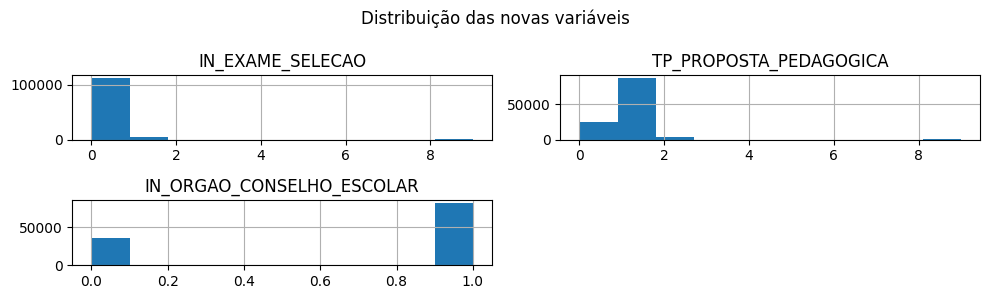

In [55]:
df[['IN_EXAME_SELECAO','TP_PROPOSTA_PEDAGOGICA','IN_ORGAO_CONSELHO_ESCOLAR']].hist(figsize=(10,3))
plt.suptitle("Distribuição das novas variáveis")
plt.tight_layout()
plt.show()

<Axes: xlabel='Aplica exame de seleção', ylabel='Taxa média de abandono'>

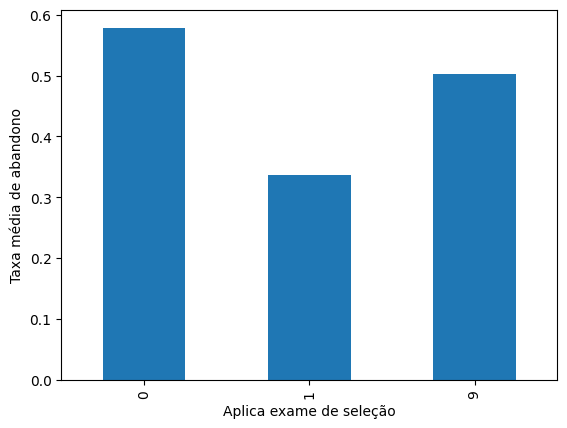

In [56]:
df.groupby('IN_EXAME_SELECAO')['3_CAT_FUN'].mean().plot(
    kind='bar',
    xlabel='Aplica exame de seleção',
    ylabel='Taxa média de abandono'
)

<Axes: xlabel='Proposta pedagógica atualizada', ylabel='Taxa média de abandono'>

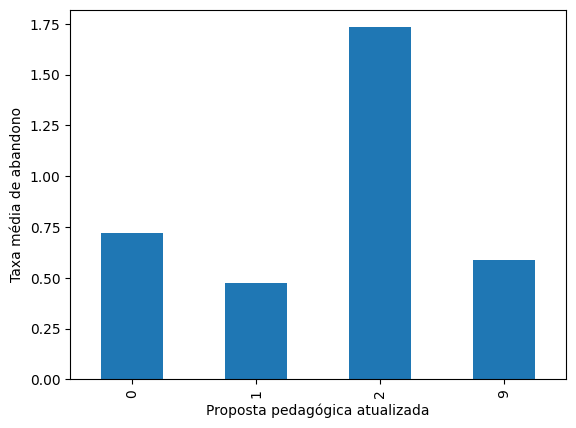

In [57]:
df.groupby('TP_PROPOSTA_PEDAGOGICA')['3_CAT_FUN'].mean().plot(
    kind='bar',
    xlabel='Proposta pedagógica atualizada',
    ylabel='Taxa média de abandono'
)

<Axes: xlabel='Possui Conselho Escolar', ylabel='Taxa média de abandono'>

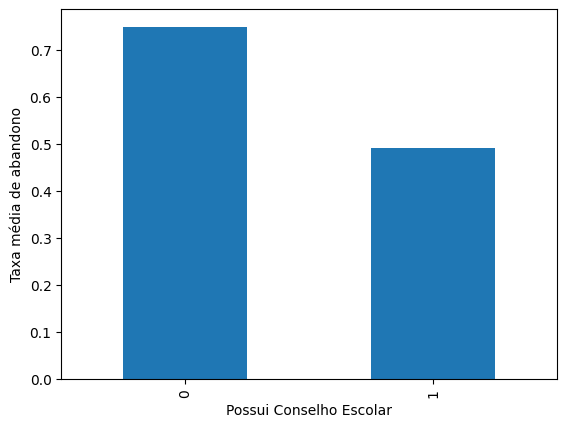

In [58]:
df.groupby('IN_ORGAO_CONSELHO_ESCOLAR')['3_CAT_FUN'].mean().plot(
    kind='bar',
    xlabel='Possui Conselho Escolar',
    ylabel='Taxa média de abandono'
)

Agora que a etapa de análise exploratória finalizou, vamos remover a variável CO_ENTIDADE do modelo, pois é apenas o identificador da escola que usamos para cruzar as informações.

#### **5. Preparação para Modelagem**

Vamos transformar o problema em uma classificação binária. Em vez de considerar qualquer taxa de abandono acima de 0% como positivo, usamos um limiar de 2%: taxas muito baixas podem refletir casos isolados (1 ou 2 alunos) ou pequenas imprecisões de registro, e não necessariamente um padrão relevante de evasão.

0 → taxa de abandono ≤ 2%

1 → taxa de abandono > 2%

In [59]:
y_class = (df['3_CAT_FUN'] > 2).astype(int)

#### **Separação de target e features**

In [60]:
X = df.drop(columns=['CO_ENTIDADE', '3_CAT_FUN']) # Features

In [61]:
X.columns

Index(['CO_REGIAO', 'CO_REDE', 'TP_DEPENDENCIA', 'TP_LOCALIZACAO',
       'TP_LOCALIZACAO_DIFERENCIADA', 'IN_EXAME_SELECAO',
       'TP_PROPOSTA_PEDAGOGICA', 'IN_ORGAO_CONSELHO_ESCOLAR'],
      dtype='object')

#### **Separação de dados de Treino e Teste**

In [62]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y_class,
    test_size=0.2, # 20% dos dados ficam para teste e 80% para treinamento
    random_state=42,
    stratify=y_class # mantém a proporção das classes em treino e teste
)

In [63]:
print(X_treino.shape)
print(X_teste.shape)
print(y_treino.shape)
print(y_teste.shape)

(93508, 8)
(23377, 8)
(93508,)
(23377,)


#### **Preparação das variáveis categóricas**

Nossas variáveis são códigos numéricos, mas não são valores contínuos. Por exemplo, CO_REDE = 1 e CO_REDE = 2 representam categorias, não significa que 2 seja "maior" que 1.

Então vamos transformar as categorias em colunas binárias através do OneHotEncoding.

In [64]:
# Todas as variáveis de X são categóricas
colunas_categoricas = X.columns.tolist()

# Criando o transformador
preprocessador = ColumnTransformer(
    transformers=[
        ('categoricas', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
    ]
)

#### **6. Modelagem com SVM**

Começamos com um SVM linear simples com ajuste para o desbalanceamento das classes (class_weight='balanced')

In [65]:
modelo_classificacao = Pipeline([
    ('preprocessamento', preprocessador),
    ('svm', LinearSVC(class_weight='balanced', max_iter=5000, random_state=42))
])

In [66]:
modelo_classificacao.fit(X_treino, y_treino)

y_pred_class = modelo_classificacao.predict(X_teste)

Acurácia: 0.6073063267314026

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.97      0.59      0.74     21654
           1       0.13      0.79      0.23      1723

    accuracy                           0.61     23377
   macro avg       0.55      0.69      0.48     23377
weighted avg       0.91      0.61      0.70     23377



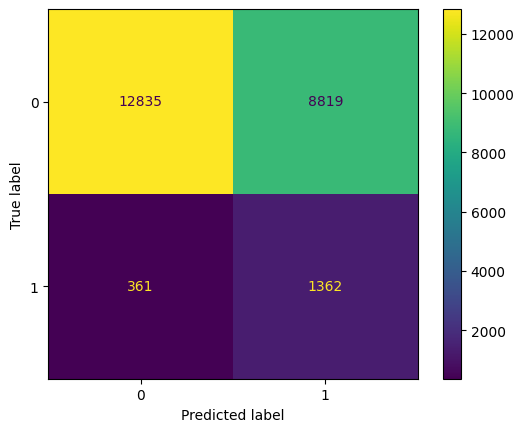

In [67]:
print("Acurácia:", accuracy_score(y_teste, y_pred_class))

print("\nRelatório de classificação:")
print(classification_report(y_teste, y_pred_class))

cm = confusion_matrix(y_teste, y_pred_class)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Com o limiar de 2%, a classe 1 (abandono) passou a representar apenas ~7% dos dados — uma imbalance bem mais forte do que quando o limiar era 0%. O modelo teve recall de 0.79 na classe 1, ou seja, identifica a maior parte das escolas com abandono relevante, mas à custa de muitos falsos positivos (precisão de apenas 0.13).

Para avaliar se o modelo está realmente aprendendo algo além da distribuição das classes, comparamos com um classificador base (baseline) que sempre prevê a classe mais frequente.

In [68]:

modelo_base_class = DummyClassifier(strategy='most_frequent')

modelo_base_class.fit(X_treino, y_treino)

y_pred_base_class = modelo_base_class.predict(X_teste)

In [69]:
print("Acurácia:", accuracy_score(y_teste, y_pred_base_class))

print("\nRelatório:")
print(classification_report(y_teste, y_pred_base_class))

Acurácia: 0.9262950763571032

Relatório:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     21654
           1       0.00      0.00      0.00      1723

    accuracy                           0.93     23377
   macro avg       0.46      0.50      0.48     23377
weighted avg       0.86      0.93      0.89     23377



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Atenção aqui: o baseline atingiu 0.93 de acurácia só por sempre prever "não houve abandono", mais alto que o próprio modelo SVM (0.61). Isso não significa que o baseline é melhor: ele simplesmente nunca identifica nenhuma escola em risco (recall = 0 na classe 1), o que o torna inútil para o objetivo do projeto. Com classes tão desbalanceadas, acurácia sozinha é uma métrica enganosa, o recall/F1 da classe 1 é o que importa aqui.

Testando diferentes valores de C via GridSearchCV, para encontrar o melhor equilíbrio entre viés e variância.

In [70]:

parametros = {
    'svm__C': [0.01, 0.1, 1, 10, 100]
}

In [71]:
grid = GridSearchCV(
    modelo_classificacao,
    parametros,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [72]:
grid.fit(X_treino,y_treino)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessamento',
                                        ColumnTransformer(transformers=[('categoricas',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['CO_REGIAO',
                                                                          'CO_REDE',
                                                                          'TP_DEPENDENCIA',
                                                                          'TP_LOCALIZACAO',
                                                                          'TP_LOCALIZACAO_DIFERENCIADA',
                                                                          'IN_EXAME_SELECAO',
                                                                          'TP_PROPOSTA_PEDAGOGICA',
                                                                          'IN_ORGAO_CONSELHO_ESCOLAR'])])),
                                       ('svm',
                                        LinearSVC(class_weight='balanced',
                                                  max_iter=5000,
                                                  random_state=42))]),
             n_jobs=-1, param_grid={'svm__C': [0.01, 0.1, 1, 10, 100]},
             scoring='f1')

In [73]:
print("Melhor C encontrado:", grid.best_params_)
print("Melhor F1 (validação cruzada):", grid.best_score_)

Melhor C encontrado: {'svm__C': 0.01}
Melhor F1 (validação cruzada): 0.23202319088311904


- modelo_classificacao → nosso SVM com class_weight='balanced'
- parametros → valores de C que serão testados
- scoring='f1' → vamos escolher pelo F1
- cv=5 → divide o treino em 5 partes para validar o modelo
- n_jobs=-1 → utiliza todos os núcleos disponíveis

O valor de C encontrado em `grid.best_params_` é usado no modelo final abaixo.

In [74]:
modelo_final = Pipeline([
    ('preprocessamento', preprocessador),
    ('svm', LinearSVC(
        C=grid.best_params_['svm__C'], # melhor valor encontrado no GridSearchCV
        class_weight='balanced',
        random_state=42,
        max_iter=5000
    ))
])

modelo_final.fit(X_treino, y_treino)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['CO_REGIAO', 'CO_REDE',
                                                   'TP_DEPENDENCIA',
                                                   'TP_LOCALIZACAO',
                                                   'TP_LOCALIZACAO_DIFERENCIADA',
                                                   'IN_EXAME_SELECAO',
                                                   'TP_PROPOSTA_PEDAGOGICA',
                                                   'IN_ORGAO_CONSELHO_ESCOLAR'])])),
                ('svm',
                 LinearSVC(C=0.01, class_weight='balanced', max_iter=5000,
                           random_state=42))])

In [75]:
y_pred_final = modelo_final.predict(X_teste)

Acurácia: 0.6065363391367583

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.97      0.59      0.74     21654
           1       0.13      0.79      0.23      1723

    accuracy                           0.61     23377
   macro avg       0.55      0.69      0.48     23377
weighted avg       0.91      0.61      0.70     23377



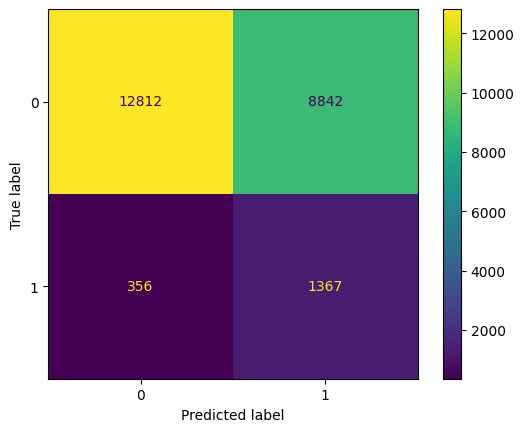

In [76]:
print("Acurácia:", accuracy_score(y_teste, y_pred_final))

print("\nRelatório de classificação:")
print(classification_report(y_teste, y_pred_final))

cm = confusion_matrix(y_teste, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Abaixo, está a comparação de acurácia e recall do baseline com o modelo SVM Linear.

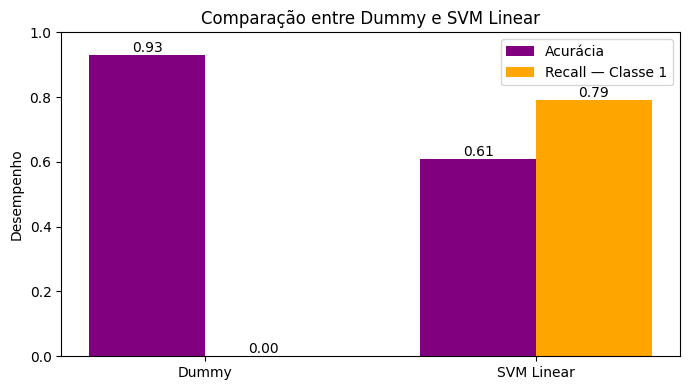

In [85]:
# Resultados dos modelos
modelos = ['Dummy', 'SVM Linear']

acuracia = [0.93, 0.61]
recall = [0.00, 0.79]

# Posição das barras
x = np.arange(len(modelos))
largura = 0.35

# Criando o gráfico
fig, ax = plt.subplots(figsize=(7, 4))

barras_acuracia = ax.bar(
    x - largura/2,
    acuracia,
    largura,
    label='Acurácia',
    color='purple'
)

barras_recall = ax.bar(
    x + largura/2,
    recall,
    largura,
    label='Recall — Classe 1',
    color='orange'
)

# Título e eixos
ax.set_title('Comparação entre Dummy e SVM Linear')
ax.set_ylabel('Desempenho')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim(0, 1)

# Valores sobre as barras
ax.bar_label(barras_acuracia, fmt='%.2f')
ax.bar_label(barras_recall, fmt='%.2f')

# Legenda
ax.legend()

plt.tight_layout()
plt.show()

A acurácia isoladamente mostrou-se inadequada para avaliar o modelo devido ao desbalanceamento das classes. O SVM reduziu a acurácia em relação ao baseline, mas aumentou o recall da classe de abandono de 0% para 79%.

#### **Conclusão**

O modelo final é um SVM linear (`LinearSVC`) com pesos balanceados entre classes e `C` escolhido via `GridSearchCV` (melhor valor: C=0.01). Ele atinge 0.61 de acurácia e, mais importante para o objetivo do projeto, recall de 0.79 na classe de abandon, contra recall 0 do baseline (`DummyClassifier`), que apenas prevê a classe majoritária.

Isso mostra que o modelo está de fato aprendendo padrões associados ao abandono, e não só repetindo a classe mais frequente, mesmo que isso custe acurácia geral e gere bastante falso positivo (precisão de 0.13 na classe 1). Esse é um trade-off esperado em problemas de triagem de risco: entre não perder nenhuma escola em situação real de abandono (alto recall) e evitar alarmes desnecessários (alta precisão), priorizamos o primeiro, já que o custo de não identificar uma escola em risco tende a ser maior do que investigar um caso que depois se mostra falso positivo.

Testamos também adicionar indicadores de infraestrutura (água, energia, esgoto, banheiro, refeitório) como features, sem ganho de desempenho, provavelmente por redundância com CO_REDE/TP_DEPENDENCIA, já presentes no modelo. Substituí-las por variáveis de outra natureza (seletividade, gestão pedagógica, governança escolar) trouxe uma melhora marginal, sugerindo que o teto de um classificador linear com features majoritariamente categóricas já está próximo de ser atingido com esse conjunto de dados.